# 04 — Final Analysis & Demo (Task 4)

**Goals (Milestone 4):**

1. Reload the best heuristic weights produced by notebook 03.
2. Compare **optimised agent vs. original agent** in a head-to-head tournament.
3. Plot win-rate vs depth and win-rate vs `n_prealloc` for the report.
4. Run a final demo game with the optimised agent.

In [6]:
import os, sys, pickle, random, time, atexit
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
import matplotlib.pyplot as plt

_here = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _here not in sys.path:
    sys.path.insert(0, _here)
import settings, tictactoe66

game        = tictactoe66.TicTacToe66()
MAX_WORKERS = os.cpu_count() or 1

# Same shared-pool trick as notebook 03: spawn workers once and reuse them.
POOL = ProcessPoolExecutor(max_workers=MAX_WORKERS)
atexit.register(POOL.shutdown, wait=False, cancel_futures=True)

print("workers:", MAX_WORKERS)

workers: 32


## 1. Load cached results & best weights

In [7]:
best_weights = pickle.loads(settings.cache_path('best_weights.pkl').read_bytes())
dfA = pickle.loads(settings.cache_path('expA_depth_vs_d1.pkl').read_bytes())
dfB = pickle.loads(settings.cache_path('expB_prealloc_sweep.pkl').read_bytes())
print('Best weights:', best_weights)

Best weights: {'w_two': 1.0, 'w_three': 20.0, 'w_block_two': 1.0, 'w_block_three': 8.0, 'w_center': 0.0, 'w_win': 10000.0}


## 2. Head-to-head: optimised vs original

In [8]:
# Parallel head-to-head between the optimised and default agents.
# The pool from cell 1 lets us run all N games concurrently instead of
# crawling through them sequentially at d=3 (~1 second per move).
def head_to_head(weights_new, weights_old, n_games, n_prealloc=2,
                 depth=settings.DEFAULT_DEPTH, seed=999):
    spec_new = (depth, weights_new)
    spec_old = (depth, weights_old)
    jobs = []
    for i in range(n_games):
        a_is_X = (i % 2 == 0)  # alternate sides to cancel first-mover bias
        per_seed = seed * 1_000_003 + i
        # spec_a is always the optimised agent so winner_label=="A" means it won.
        jobs.append((spec_new, spec_old, n_prealloc, per_seed, a_is_X, i))
    results = list(POOL.map(tictactoe66._play_one_worker, jobs, chunksize=1))
    return pd.DataFrame(results)


def score(df):
    """Aggregate W/L/D from the optimised agent's perspective."""
    wins   = (df["winner_label"] == "A").sum()
    losses = (df["winner_label"] == "B").sum()
    draws  = (df["winner_label"] == "draw").sum()
    return wins, losses, draws


h2h = head_to_head(best_weights,
                   settings.DEFAULT_HEURISTIC_WEIGHTS,
                   n_games=settings.N_GAMES_PER_CONFIG)
w, l, d = score(h2h)
n = len(h2h)
print(f"Optimised vs Original  ->  W:{w}  L:{l}  D:{d}  ({n} games)")
print(f"win rate {w/n:.3f}  (SE ≈ {((w/n)*(1-w/n)/n)**0.5:.3f})")
print(f"mean plies: {h2h['plies'].mean():.2f}")

Optimised vs Original  ->  W:40  L:34  D:6  (80 games)
win rate 0.500  (SE ≈ 0.056)
mean plies: 15.50


## 3. Plots for the report

saved C:\Git\AI801Project\cache\figures\final_summary.png


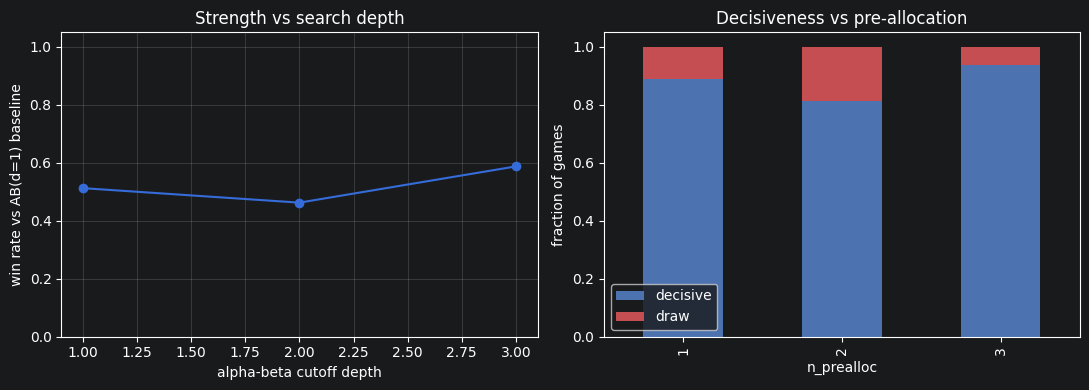

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) Win-rate of deeper alpha-beta vs an AB(d=1) baseline.
wr_depth = (dfA.assign(win=lambda d: d["winner_label"] == "deep")
                .groupby("depth")["win"].mean())
axes[0].plot(wr_depth.index, wr_depth.values, "o-")
axes[0].set_xlabel("alpha-beta cutoff depth")
axes[0].set_ylabel("win rate vs AB(d=1) baseline")
axes[0].set_title("Strength vs search depth")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# (b) Decisiveness vs pre-allocation.  Sides are alternated in expB so the
# X/O split is meaningless; what matters is how often the game ends in a win.
agg_B = (dfB.groupby("n_prealloc")
             .agg(decisive=("winner", lambda s: (s != "draw").mean()),
                  draw    =("winner", lambda s: (s == "draw").mean())))
agg_B[["decisive", "draw"]].plot(kind="bar", stacked=True, ax=axes[1],
                                   color=["#4C72B0", "#C44E52"])
axes[1].set_ylabel("fraction of games")
axes[1].set_title("Decisiveness vs pre-allocation")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title=None)

plt.tight_layout()
out = settings.FIGURES_DIR / "final_summary.png"
plt.savefig(out, dpi=120)
print("saved", out)
plt.show()

## 4. Final demo game (optimised agent)

In [10]:
# Final demo: a single game played by two copies of the optimised agent.
p_demo = tictactoe66.make_alpha_beta_player(depth=settings.DEFAULT_DEPTH,
                                              weights=best_weights,
                                              name="AB-optimised")
rng = random.Random(2026)
res = tictactoe66.play_one_game(game, p_demo, p_demo,
                                 n_prealloc=2, rng=rng, display=True)
print("outcome:", res)

     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimised -> (3, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimised -> (1, 1)
     1  2  3  4  5  6
   +------------------+
 1 |  O  .  .  .  .  . |
 2 |  O  X  .  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimised -> (2, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  O  .  .  .  .  . |
 2 |  O  X  X  .  .  . |
 3 |  .  .  X  .  .  . |
 4 |  .  .  X  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  O  .  .  . |
   +------------------+

AB-optimised -> (1, 2)
     1  2  3  4  5  6
  

**Milestone 4 reached.** All deliverables — code, cached experimental data, and figures — are in place. The written report and slide deck reference `cache/figures/final_summary.png` and the summary tables produced above.